# 02 · Desempenho e abstenção

**Perguntas:** qual o tamanho da abstenção e onde ela é maior? Quão grande é o fosso
entre escola pública e privada em cada área do conhecimento?

**Dados:** agregados de `RESULTADOS_2024.csv`. Em 2024, o dia 1 (03/11) teve Linguagens (LC),
Humanas (CH) e Redação; o dia 2 (10/11), Natureza (CN) e Matemática (MT).
A dependência administrativa vem do Censo Escolar 2024 e só existe para prováveis
concluintes localizados no Censo — os demais aparecem como "sem escola identificada".

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from enem2024 import labels, plots
from enem2024.data import load

plots.setup()
GRAY = plots.BASELINE  # de-ênfase


## Abstenção: 3 em cada 10 inscritos não fizeram o dia 2

In [2]:
pres = load("presenca").pivot(index="presenca", columns="area", values="n")
abst = (pres.loc[0] / pres.sum())
print("Abstenção por prova:")
print((abst * 100).round(1).astype(str) + " %")

Abstenção por prova:
area
CH    26.8 %
CN    30.6 %
LC    26.8 %
MT    30.6 %
dtype: str


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


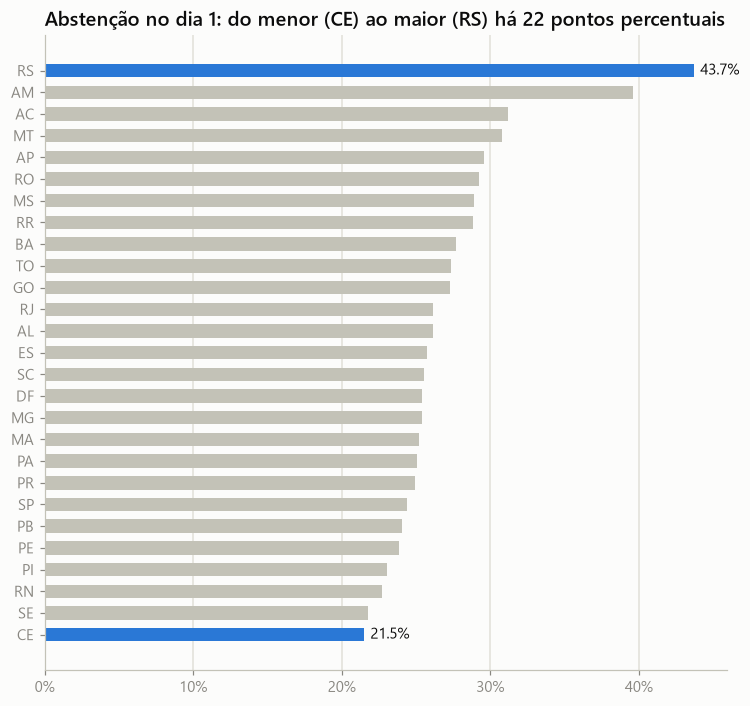

In [3]:
duf = load("desempenho_uf").sort_values("abstencao_dia1")
extremos = {duf.iloc[0]["uf"], duf.iloc[-1]["uf"]}

fig, ax = plt.subplots(figsize=(8, 7.5))
colors = [plots.BLUE if u in extremos else GRAY for u in duf["uf"]]
ax.barh(duf["uf"], duf["abstencao_dia1"], color=colors, height=0.62)
for uf in extremos:
    row = duf[duf.uf == uf].iloc[0]
    ax.annotate(f"{row.abstencao_dia1:.1%}", (row.abstencao_dia1, row.uf),
                va="center", ha="left", fontsize=9.5, color=plots.INK,
                xytext=(4, 0), textcoords="offset points")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Abstenção no dia 1: do menor (CE) ao maior (RS) há 22 pontos percentuais")
ax.grid(axis="y", visible=False)
plots.save_fig(fig, "04_abstencao_uf")
plt.show()

O Rio Grande do Sul, atingido pelas enchentes de 2024, lidera a abstenção (43,7%) com folga sobre o segundo colocado — hipótese plausível, mas os microdados não trazem o motivo da falta.

## Público × privado: o fosso por área de conhecimento

Boxplots sobre uma amostra aleatória de 200 mil participantes com nota (agregações completas estão em `data/processed`). Estadual e municipal foram agrupadas como "Pública"; federais (IFs, colégios militares etc.) ficam à parte porque se comportam como outra rede.

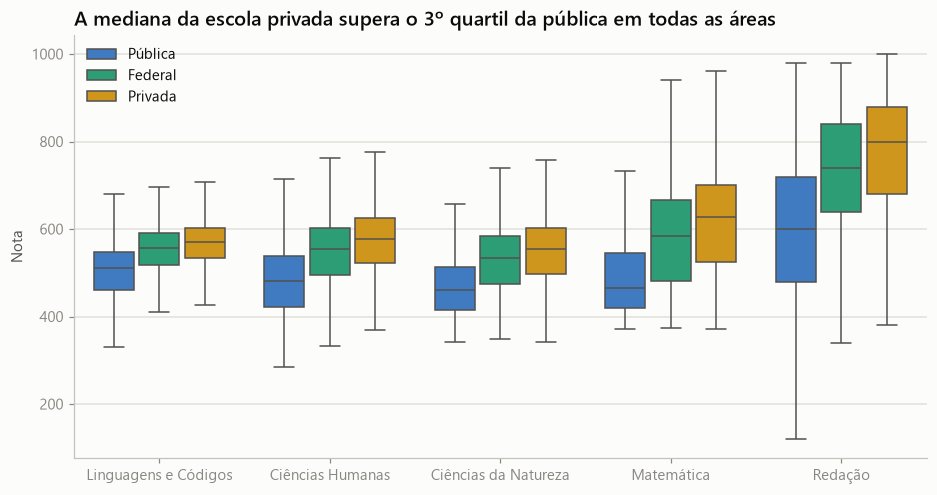

In [4]:
am = load("amostra_notas")
am = am.assign(grupo=am["dependencia"].map({1: "Federal", 2: "Pública", 3: "Pública", 4: "Privada"}))
long = (
    am.dropna(subset=["grupo"])
      .melt(id_vars="grupo", value_vars=["nota_cn", "nota_ch", "nota_lc", "nota_mt", "nota_redacao"],
            var_name="area", value_name="nota")
      .dropna(subset=["nota"])
)
long["area"] = long["area"].str.removeprefix("nota_").str.upper().map(labels.AREAS)

ordem_areas = [labels.AREAS[a] for a in ["LC", "CH", "CN", "MT", "REDACAO"]]
grupos = ["Pública", "Federal", "Privada"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=long, x="area", y="nota", hue="grupo", order=ordem_areas, hue_order=grupos,
    palette=dict(zip(grupos, plots.CATEGORICAL[:3])), showfliers=False,
    linewidth=1.0, linecolor=plots.INK_SECONDARY, gap=0.12, ax=ax,
)
ax.set_title("A mediana da escola privada supera o 3º quartil da pública em todas as áreas")
ax.set_xlabel("")
ax.set_ylabel("Nota")
ax.legend(title="", loc="upper left")
plots.save_fig(fig, "05_publico_privado")
plt.show()

In [5]:
de = load("desempenho_escola")
grupo = de["dependencia"].map({1: "Federal", 2: "Pública", 3: "Pública", 4: "Privada"})
de = de.assign(grupo=grupo).dropna(subset=["grupo"])

def media_pond(d, col):
    return (d[col] * d["n"]).sum() / d["n"].sum()

gaps = pd.DataFrame({
    g: {a: media_pond(de[de.grupo == g], f"media_{a.lower()}")
        for a in ["LC", "CH", "CN", "MT", "REDACAO"]}
    for g in ["Pública", "Federal", "Privada"]
}).round(1)
gaps["gap privada-pública"] = (gaps["Privada"] - gaps["Pública"]).round(1)
gaps

,Pública,Federal,Privada,gap privada-pública
LC,501.4,550.4,564.5,63.1
CH,479.3,543.6,569.4,90.1
CN,466.2,528.2,549.0,82.8
MT,489.8,579.3,616.1,126.3
REDACAO,573.9,720.9,765.6,191.7


## Urbana × rural

In [6]:
loc_ = load("desempenho_escola").dropna(subset=["localizacao"])
tab = pd.DataFrame({
    labels.LOCALIZACAO[k]: {a: media_pond(loc_[loc_.localizacao == k], f"media_{a.lower()}")
                            for a in ["LC", "CH", "CN", "MT", "REDACAO"]}
    for k in (1, 2)
}).round(1)
tab["diferença"] = (tab["Urbana"] - tab["Rural"]).round(1)
tab

,Urbana,Rural,diferença
LC,515.8,482.9,32.9
CH,499.0,463.1,35.9
CN,484.1,458.8,25.3
MT,516.7,479.2,37.5
REDACAO,616.0,544.2,71.8


## Inglês × espanhol

  lingua       n  media_lc  mediana_lc
  Inglês 1842028     541.4       548.8
Espanhol 1325927     500.9       507.8


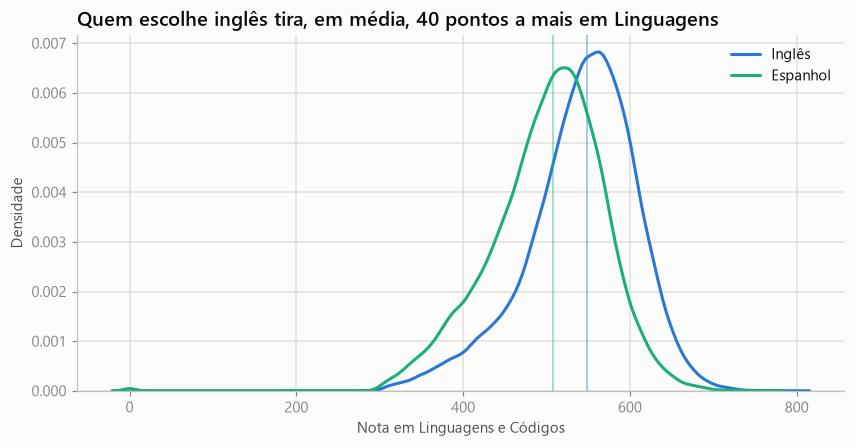

In [7]:
lg = load("lingua")
lg["lingua"] = lg["lingua"].map(labels.LINGUA)
print(lg.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.2))
for i, (nome, cor) in enumerate(zip(["Inglês", "Espanhol"], plots.CATEGORICAL[:2])):
    dados = am.loc[am["lingua"] == i, "nota_lc"].dropna()
    sns.kdeplot(dados, ax=ax, color=cor, label=nome, linewidth=2)
    med = dados.median()
    ax.axvline(med, color=cor, linewidth=1, alpha=0.5)
ax.set_title("Quem escolhe inglês tira, em média, 40 pontos a mais em Linguagens")
ax.set_xlabel("Nota em Linguagens e Códigos")
ax.set_ylabel("Densidade")
ax.legend()
plt.show()

A diferença não significa que estudar inglês melhora a nota: a escolha da língua é socialmente estratificada (inglês é mais frequente entre alunos de escolas privadas).

## Bônus · TRI: qual prova teve os itens mais difíceis?

C:\Users\nevef\AppData\Local\Temp\ipykernel_17924\3567859591.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([labels.AREAS[a] for a in ordem])


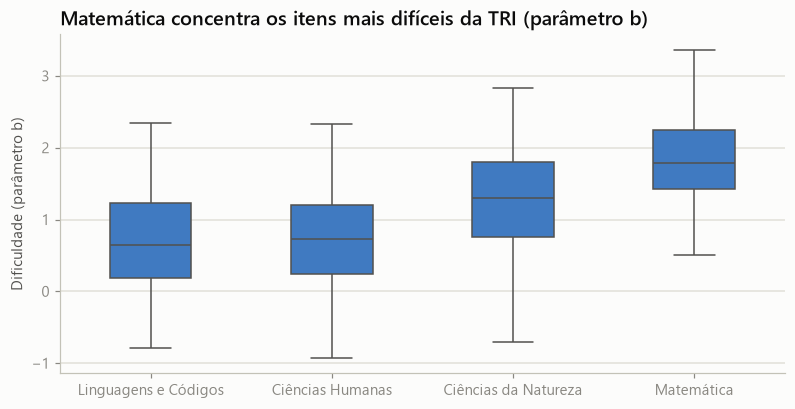

In [8]:
itens = load("itens")
validos = itens[(itens.IN_ITEM_ABAN == 0) & itens.NU_PARAM_B.notna()]
ordem = validos.groupby("SG_AREA")["NU_PARAM_B"].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(8.5, 4))
sns.boxplot(data=validos, x="SG_AREA", y="NU_PARAM_B", order=ordem,
            color=plots.BLUE, showfliers=False, linewidth=1.0,
            linecolor=plots.INK_SECONDARY, width=0.45, ax=ax)
ax.set_xticklabels([labels.AREAS[a] for a in ordem])
ax.set_title("Matemática concentra os itens mais difíceis da TRI (parâmetro b)")
ax.set_xlabel("")
ax.set_ylabel("Dificuldade (parâmetro b)")
plt.show()

## Conclusões

1. **Abstenção de 26,8% no dia 1 e 30,6% no dia 2.** No RS (enchentes de 2024) chegou a
   **43,7%**, 22 p.p. acima do CE (21,5%).
2. **O fosso público × privado é enorme e cresce nas áreas mais "treináveis"**: 63 pontos em
   Linguagens, 126 em Matemática e **192 na Redação**. As federais se comportam como as privadas.
3. Escolas **rurais** ficam ~30–40 pontos abaixo das urbanas em todas as áreas.
4. Quem escolhe **inglês** supera quem escolhe espanhol em ~40 pontos na média de LC —
   diferença que reflete estratificação social, não causalidade.
5. Pela TRI, **Matemática teve os itens mais difíceis** (parâmetro b mediano ≈ 1,9).